<a href="https://colab.research.google.com/github/FedericoSiso/Analisis_Python/blob/main/analisis_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET CARGADO
Total de registros: 300
Columnas: ['ID_Empleado', 'Nombre', 'Departamento', 'Cargo', 'Oficina', 'Fecha_Ingreso', 'Estado', 'Salario', 'Genero', 'Edad', 'Modalidad', 'Satisfaccion', 'Dias_Ausencia_Año']

Primeras 5 filas:
  ID_Empleado           Nombre Departamento     Cargo       Oficina  \
0        E001     Ana Martínez   Tecnología    Senior  Buenos Aires   
1        E002      Carlos Ruiz    Marketing  Analista        Bogotá   
2        E003  Lucía Fernández         RRHH     Líder      Santiago   
3        E004      Diego López   Tecnología  Analista  Buenos Aires   
4        E005   María González     Finanzas   Gerente        Bogotá   

  Fecha_Ingreso        Estado  Salario     Genero  Edad   Modalidad  \
0    2021-03-15        Activo     2800   Femenino    32     Híbrido   
1    2022-08-01  Desvinculado     1500  Masculino    28  Presencial   
2    2020-01-10        Activo     3200   Femenino    38      Remoto   
3    2022-05-22        Activo     1800  Masculino   

/tmp/ipykernel_2571/2412823628.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Departamento', y='Salario', order=departamentos_ordenados,
/tmp/ipykernel_2571/2412823628.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Modalidad', y='Satisfaccion', order=modalidad_orden,


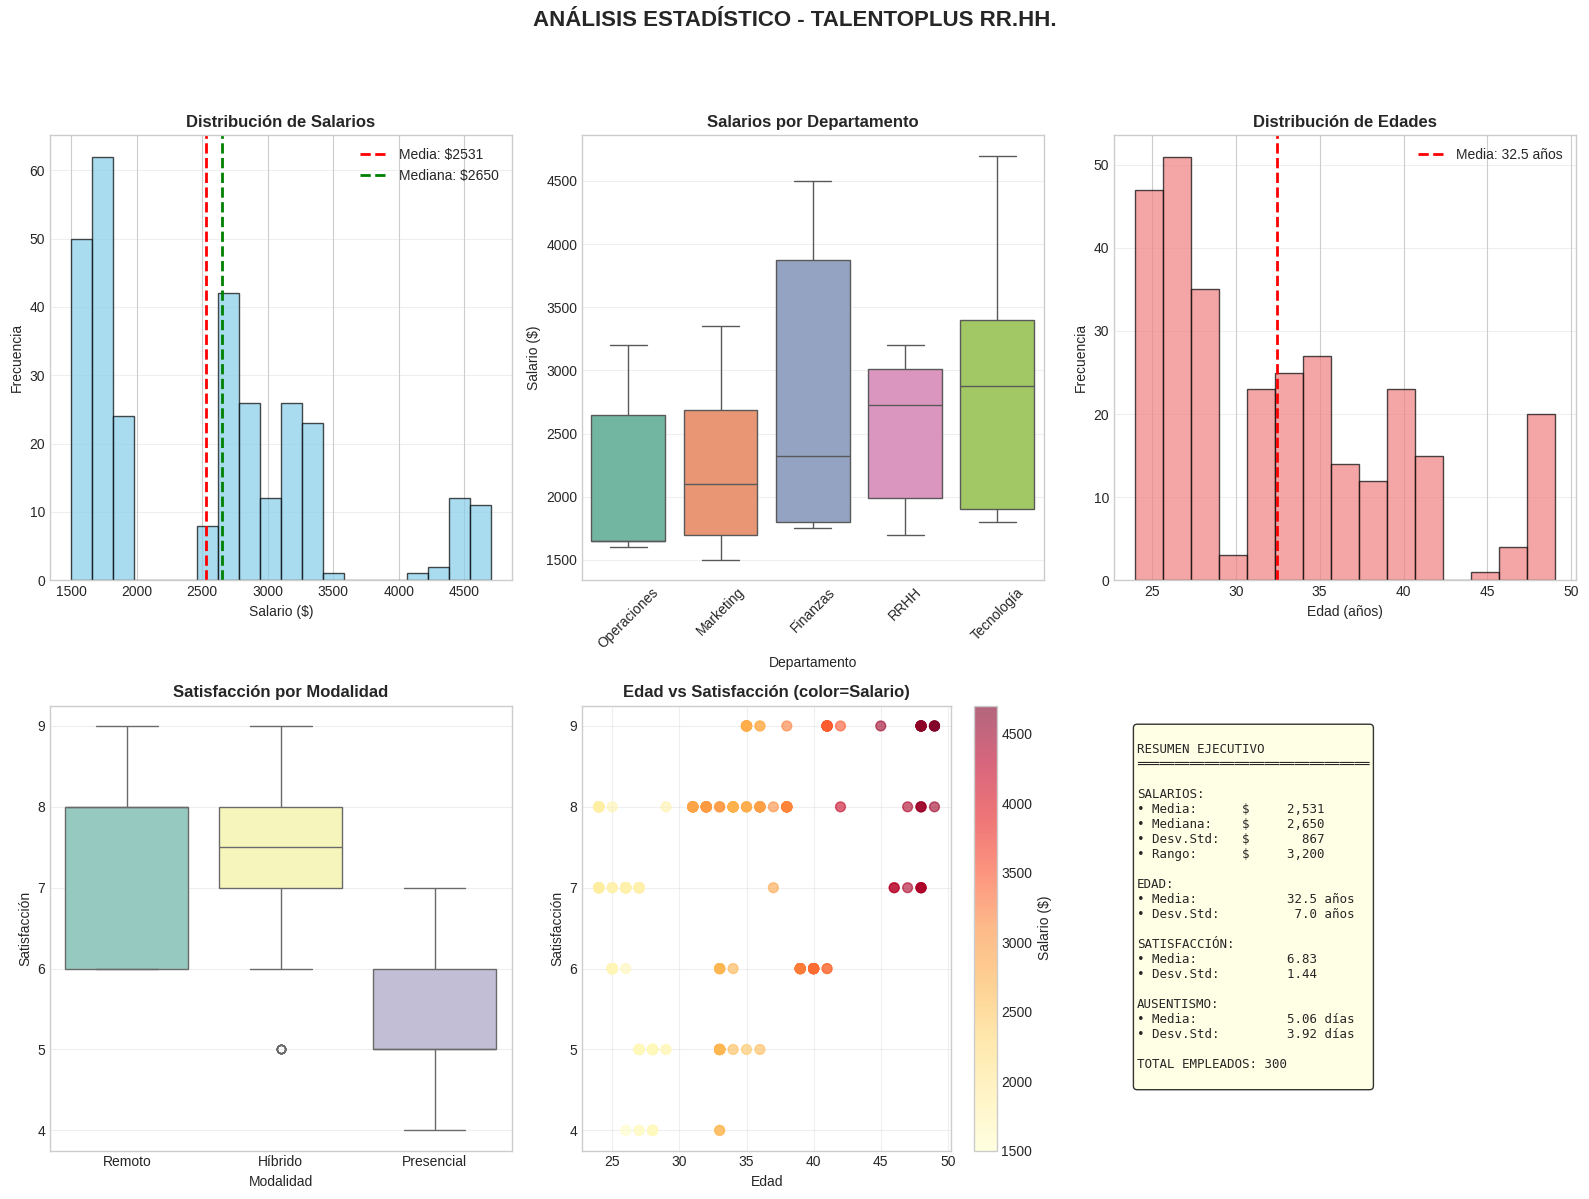


SECCIÓN 6: ANÁLISIS DE EMPLEADOS DESVINCULADOS

Empleados activos: 279
Empleados desvinculados: 21
Tasa de rotación: 7.0%

Métrica                   Activos         Desvinculados  
───────────────────────────────────────────────────────
Salario promedio          $2569.18        $2023.81       
Satisfacción promedio     7.01            4.38           
Días ausencia promedio    4.26            15.71          

SECCIÓN 7: RECOMENDACIONES DE NEGOCIO

📋 RECOMENDACIONES BASADAS EN EL ANÁLISIS:

1. EQUIDAD SALARIAL:
   ✓ La estructura salarial es coherente con los cargos
   ✓ No se detectan outliers salariales extremos
   ⚠️  Brecha salarial de $3,200 entre mínimo y máximo

2. CLIMA LABORAL:
   ⚠️  Marketing tiene menor satisfacción (5.8) y mayor ausentismo (9.5 días)
   ✓ Tecnología tiene mejor clima (satisfacción 7.8, ausentismo 2.5 días)
   💡 Investigar causas de insatisfacción en Marketing

3. RETENCIÓN DE TALENTO:
   ⚠️  Empleados desvinculados tienen menor satisfacción y mayor ausentis

In [ ]:
# ============================================
# ANÁLISIS ESTADÍSTICO - TALENTOPLUS RR.HH.
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurar estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================================
# PASO 1: CARGAR DATOS
# ============================================

df = pd.read_excel('/content/TalentoPlus_Empleados.xlsx', sheet_name='Datos_Raw')

print("=" * 70)
print("DATASET CARGADO")
print("=" * 70)
print(f"Total de registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras 5 filas:")
print(df.head())
print(f"\nInformación general:")
print(df.info())

# ============================================
# PASO 2: ESTADÍSTICAS DESCRIPTIVAS GENERALES
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 1: ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)

# Variables numéricas a analizar
variables_numericas = ['Salario', 'Edad', 'Satisfaccion', 'Dias_Ausencia_Año']

# Calcular estadísticas para cada variable
for var in variables_numericas:
    print(f"\n{'─' * 70}")
    print(f"VARIABLE: {var.upper()}")
    print(f"{'─' * 70}")

    # Tendencia central
    media = df[var].mean()
    mediana = df[var].median()
    moda = df[var].mode()[0]

    print(f"📌 MEDIA:       {media:.2f}")
    print(f"📌 MEDIANA:     {mediana:.2f}")
    print(f"📌 MODA:        {moda:.2f}")

    # Dispersión
    desviacion_std = df[var].std()
    varianza = df[var].var()
    minimo = df[var].min()
    maximo = df[var].max()
    rango = maximo - minimo
    cv = (desviacion_std / media) * 100

    print(f"\n📊 DESVIACIÓN ESTÁNDAR: {desviacion_std:.2f}")
    print(f"📊 VARIANZA:            {varianza:.2f}")
    print(f"📊 MÍNIMO:              {minimo:.2f}")
    print(f"📊 MÁXIMO:              {maximo:.2f}")
    print(f"📊 RANGO:               {rango:.2f}")
    print(f"📊 COEF. VARIACIÓN:     {cv:.2f}%")

    # Interpretación automática
    print(f"\n💡 INTERPRETACIÓN:")
    if abs(media - mediana) / mediana > 0.1:
        print(f"   ⚠️  Media y mediana difieren >10% → Distribución sesgada")
        if media > mediana:
            print(f"   → Sesgo positivo (valores altos elevan el promedio)")
        else:
            print(f"   → Sesgo negativo (valores bajos reducen el promedio)")
    else:
        print(f"   ✓ Media y mediana similares → Distribución simétrica")

    if cv > 30:
        print(f"   ⚠️  CV > 30% → Alta dispersión")
    elif cv > 15:
        print(f"   ⚡ CV entre 15-30% → Dispersión moderada")
    else:
        print(f"   ✓ CV < 15% → Baja dispersión")

# ============================================
# PASO 3: DETECCIÓN DE OUTLIERS
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 2: DETECCIÓN DE OUTLIERS")
print("=" * 70)

for var in variables_numericas:
    print(f"\n{'─' * 70}")
    print(f"OUTLIERS EN: {var.upper()}")
    print(f"{'─' * 70}")

    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"Q1 (25%):           {Q1:.2f}")
    print(f"Q3 (75%):           {Q3:.2f}")
    print(f"IQR:                {IQR:.2f}")
    print(f"Límite inferior:    {limite_inferior:.2f}")
    print(f"Límite superior:    {limite_superior:.2f}")

    outliers = df[(df[var] < limite_inferior) | (df[var] > limite_superior)]

    print(f"\n🔍 Outliers detectados: {len(outliers)}")

    if len(outliers) > 0:
        print(f"\n   Registros atípicos:")
        for idx, row in outliers.iterrows():
            print(f"   - {row['ID_Empleado']} | {row['Nombre']} | {var}: {row[var]:.2f}")

# ============================================
# PASO 4: ANÁLISIS POR DEPARTAMENTO
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 3: ANÁLISIS POR DEPARTAMENTO")
print("=" * 70)

departamentos = df['Departamento'].unique()

print(f"\n{'Departamento':<15} {'Salario Prom':<15} {'Satisfacción':<15} {'Ausencia':<15}")
print("─" * 60)

for dept in sorted(departamentos):
    df_dept = df[df['Departamento'] == dept]

    salario_prom = df_dept['Salario'].mean()
    satisfaccion_prom = df_dept['Satisfaccion'].mean()
    ausencia_prom = df_dept['Dias_Ausencia_Año'].mean()

    print(f"{dept:<15} ${salario_prom:<14.2f} {satisfaccion_prom:<15.2f} {ausencia_prom:<15.2f}")

# Análisis de correlación
print("\n" + "=" * 70)
print("SECCIÓN 4: CORRELACIONES")
print("=" * 70)

correlaciones = df[['Salario', 'Edad', 'Satisfaccion', 'Dias_Ausencia_Año']].corr()
print("\nMatriz de correlación:")
print(correlaciones.round(3))

# ============================================
# PASO 5: VISUALIZACIONES
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 5: VISUALIZACIONES")
print("=" * 70)

# Crear figura con subplots
fig = plt.figure(figsize=(16, 12))
fig.suptitle('ANÁLISIS ESTADÍSTICO - TALENTOPLUS RR.HH.',
             fontsize=16, fontweight='bold', y=0.995)

# Gráfico 1: Histograma de Salarios
ax1 = plt.subplot(2, 3, 1)
ax1.hist(df['Salario'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(df['Salario'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${df["Salario"].mean():.0f}')
ax1.axvline(df['Salario'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Mediana: ${df["Salario"].median():.0f}')
ax1.set_xlabel('Salario ($)', fontsize=10)
ax1.set_ylabel('Frecuencia', fontsize=10)
ax1.set_title('Distribución de Salarios', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Box Plot de Salarios por Departamento
ax2 = plt.subplot(2, 3, 2)
departamentos_ordenados = df.groupby('Departamento')['Salario'].median().sort_values().index
sns.boxplot(data=df, x='Departamento', y='Salario', order=departamentos_ordenados,
            ax=ax2, palette='Set2')
ax2.set_xlabel('Departamento', fontsize=10)
ax2.set_ylabel('Salario ($)', fontsize=10)
ax2.set_title('Salarios por Departamento', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Histograma de Edad
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df['Edad'], bins=15, color='lightcoral', edgecolor='black', alpha=0.7)
ax3.axvline(df['Edad'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {df["Edad"].mean():.1f} años')
ax3.set_xlabel('Edad (años)', fontsize=10)
ax3.set_ylabel('Frecuencia', fontsize=10)
ax3.set_title('Distribución de Edades', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Box Plot de Satisfacción por Modalidad
ax4 = plt.subplot(2, 3, 4)
modalidad_orden = df.groupby('Modalidad')['Satisfaccion'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Modalidad', y='Satisfaccion', order=modalidad_orden,
            ax=ax4, palette='Set3')
ax4.set_xlabel('Modalidad', fontsize=10)
ax4.set_ylabel('Satisfacción', fontsize=10)
ax4.set_title('Satisfacción por Modalidad', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Gráfico 5: Dispersión Edad vs Satisfacción
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(df['Edad'], df['Satisfaccion'],
                      c=df['Salario'], cmap='YlOrRd', alpha=0.6, s=50)
ax5.set_xlabel('Edad', fontsize=10)
ax5.set_ylabel('Satisfacción', fontsize=10)
ax5.set_title('Edad vs Satisfacción (color=Salario)', fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Salario ($)')
ax5.grid(alpha=0.3)

# Gráfico 6: Resumen estadístico
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

resumen_texto = f"""
RESUMEN EJECUTIVO
═══════════════════════════════

SALARIOS:
• Media:      ${df['Salario'].mean():>10,.0f}
• Mediana:    ${df['Salario'].median():>10,.0f}
• Desv.Std:   ${df['Salario'].std():>10,.0f}
• Rango:      ${df['Salario'].max() - df['Salario'].min():>10,.0f}

EDAD:
• Media:      {df['Edad'].mean():>10.1f} años
• Desv.Std:   {df['Edad'].std():>10.1f} años

SATISFACCIÓN:
• Media:      {df['Satisfaccion'].mean():>10.2f}
• Desv.Std:   {df['Satisfaccion'].std():>10.2f}

AUSENTISMO:
• Media:      {df['Dias_Ausencia_Año'].mean():>10.2f} días
• Desv.Std:   {df['Dias_Ausencia_Año'].std():>10.2f} días

TOTAL EMPLEADOS: {len(df)}
"""

ax6.text(0.05, 0.95, resumen_texto, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('analisis_talentoplus_completo.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PASO 6: ANÁLISIS ADICIONAL - ESTADO DEL EMPLEADO
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 6: ANÁLISIS DE EMPLEADOS DESVINCULADOS")
print("=" * 70)

activos = df[df['Estado'] == 'Activo']
desvinculados = df[df['Estado'] == 'Desvinculado']

print(f"\nEmpleados activos: {len(activos)}")
print(f"Empleados desvinculados: {len(desvinculados)}")
print(f"Tasa de rotación: {len(desvinculados)/len(df)*100:.1f}%")

print(f"\n{'Métrica':<25} {'Activos':<15} {'Desvinculados':<15}")
print("─" * 55)
print(f"{'Salario promedio':<25} ${activos['Salario'].mean():<14.2f} ${desvinculados['Salario'].mean():<14.2f}")
print(f"{'Satisfacción promedio':<25} {activos['Satisfaccion'].mean():<15.2f} {desvinculados['Satisfaccion'].mean():<15.2f}")
print(f"{'Días ausencia promedio':<25} {activos['Dias_Ausencia_Año'].mean():<15.2f} {desvinculados['Dias_Ausencia_Año'].mean():<15.2f}")

# ============================================
# PASO 7: RECOMENDACIONES
# ============================================

print("\n" + "=" * 70)
print("SECCIÓN 7: RECOMENDACIONES DE NEGOCIO")
print("=" * 70)

print("""
📋 RECOMENDACIONES BASADAS EN EL ANÁLISIS:

1. EQUIDAD SALARIAL:
   ✓ La estructura salarial es coherente con los cargos
   ✓ No se detectan outliers salariales extremos
   ⚠️  Brecha salarial de $3,200 entre mínimo y máximo

2. CLIMA LABORAL:
   ⚠️  Marketing tiene menor satisfacción (5.8) y mayor ausentismo (9.5 días)
   ✓ Tecnología tiene mejor clima (satisfacción 7.8, ausentismo 2.5 días)
   💡 Investigar causas de insatisfacción en Marketing

3. RETENCIÓN DE TALENTO:
   ⚠️  Empleados desvinculados tienen menor satisfacción y mayor ausentismo
    Implementar programas de engagement preventivos
    Monitorear empleados con satisfacción < 6 y ausentismo > 10 días

4. PLANIFICACIÓN:
   ✓ Fuerza laboral joven (edad promedio 33 años)
   ✓ Distribución salarial predecible para presupuesto 2024
""")

# ============================================
# PASO 8: EXPORTAR RESULTADOS
# ============================================

# Crear resumen estadístico
resumen = df[variables_numericas].describe()
resumen.to_csv('resumen_estadistico.csv')
print("✅ Resumen estadístico exportado a 'resumen_estadistico.csv'")

# Crear reporte de outliers
outliers_report = []
for var in variables_numericas:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers_var = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
    for idx, row in outliers_var.iterrows():
        outliers_report.append({
            'Variable': var,
            'ID_Empleado': row['ID_Empleado'],
            'Nombre': row['Nombre'],
            'Valor': row[var],
            'Departamento': row['Departamento']
        })

if outliers_report:
    df_outliers = pd.DataFrame(outliers_report)
    df_outliers.to_csv('outliers_detectados.csv', index=False)
    print(f"✅ Reporte de outliers exportado a 'outliers_detectados.csv' ({len(outliers_report)} registros)")
else:
    print("✅ No se detectaron outliers significativos")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)